<a href="https://colab.research.google.com/github/anamelbsi/projeto-ic-segmentacao/blob/main/segmentacao_corpos_dagua/YOLOv11/yolov11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q ultralytics
!pip install -q opencv-python-headless
!pip install -q rasterio
!pip install -q Pillow
!pip install -q matplotlib
!pip install -q tqdm
!pip install -q seaborn
!pip install -q albumentations
!pip install -q scikit-learn

import os
import sys
import random
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
plt.style.use('ggplot')

COLORS = plt.cm.tab20c(np.linspace(0, 1, 20))

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


from ultralytics import YOLO

#constantes
CLASS_NAMES = [
    'Urban fabric', 'Industrial or commercial units', 'Arable land',
    'Permanent crops', 'Pastures', 'Complex cultivation patterns',
    'Agro-forestry areas', 'Broad-leaved forest', 'Coniferous forest',
    'Mixed forest', 'Transitional woodland, shrub',
    'Moors, heathland and sclerophyllous vegetation',
    'Natural grassland and sparsely vegetated areas', 'Beaches, dunes, sands',
    'Inland wetlands', 'Coastal wetlands', 'Inland waters', 'Marine waters',
    'Land principally occupied by agriculture'
]

NUM_CLASSES = len(CLASS_NAMES)

#funções utilitárias
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

def print_memory_usage():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9

#definir seed para reprodutibilidade
set_seed(42)

#estrutura de diretórios
base_dirs = ['data', 'models', 'results', 'visualizations']
for dir_name in base_dirs:
    os.makedirs(dir_name, exist_ok=True)


import platform

TOTAL_SAMPLES = 1000
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

In [ ]:
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class Sentinel2YOLODataset(Dataset):
    def __init__(self, num_samples=200, img_size=640, mode='train', augment=False):
        self.img_size = img_size
        self.num_samples = num_samples
        self.mode = mode
        self.augment = augment and mode == 'train'
        self.num_classes = NUM_CLASSES

        self.transform = self._get_transforms()

    def _get_transforms(self):
        if self.augment:
            return A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.HueSaturationValue(p=0.3),
                A.GaussNoise(p=0.2),
                A.CLAHE(p=0.2),
                A.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='yolo',
                                       label_fields=['class_labels']))
        else:
            return A.Compose([
                A.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='yolo',
                                       label_fields=['class_labels']))

    def _simulate_sentinel2_bands(self):
        """Simula 10 bandas do Sentinel-2 com características espectrais realísticas"""
        bands = {}

        #sentinel-2 com resoluções espaciais características
        #B02, B03, B04, B08 (10m)
        #B05, B06, B07, B8A, B11, B12 (20m)
        1
        #diferentes texturas
        base_noise = np.random.randn(self.img_size, self.img_size)

        #B02 - azul (483nm)
        bands['B02'] = self._create_spectral_band(base_noise, wavelength=0.483)

        #B03 - verde (560nm)
        bands['B03'] = self._create_spectral_band(base_noise, wavelength=0.560)

        #B04 - vermelho (665nm)
        bands['B04'] = self._create_spectral_band(base_noise, wavelength=0.665)

        #B08 - NIR (842nm)
        bands['B08'] = self._create_spectral_band(base_noise, wavelength=0.842, is_nir=True)

        #bandas de 20m (downsample e upsample para simular menor resolução)
        for i, wavelength in enumerate([0.705, 0.740, 0.783, 0.865, 1.610, 2.190]):
            band_name = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12'][i]
            bands[band_name] = self._create_lower_res_band(base_noise, wavelength)

        return bands

    def _create_spectral_band(self, base, wavelength, is_nir=False):
        """Cria uma banda espectral com características específicas"""
        band = base.copy()

        #padrões de vegetação (para NIR)
        if is_nir:
            x = np.linspace(-5, 5, self.img_size)
            y = np.linspace(-5, 5, self.img_size)
            X, Y = np.meshgrid(x, y)
            vegetation_pattern = 0.4 * np.sin(X * 0.3) * np.cos(Y * 0.3)
            band += vegetation_pattern

        #ruído correlacionado com comprimento de onda
        wavelength_factor = wavelength * 0.5
        band += wavelength_factor * np.random.randn(self.img_size, self.img_size) * 0.1

        #normalizar
        band = (band - band.mean()) / (band.std() + 1e-8)

        return band

    def _create_lower_res_band(self, base, wavelength):
        """Simula banda de menor resolução (20m)"""
        #downsample para simular resolução mais baixa
        low_res_size = self.img_size // 2
        low_res = cv2.resize(base, (low_res_size, low_res_size))

        #características espectrais
        low_res = self._create_spectral_band(low_res, wavelength)

        #upsample de volta para tamanho original
        band = cv2.resize(low_res, (self.img_size, self.img_size))

        return band

    def _create_rgb_composite(self, bands):
        """Cria composição RGB a partir das bandas Sentinel-2"""
        #composição colorida natural (B04, B03, B02)
        rgb = np.stack([
            bands['B04'],  # Red
            bands['B03'],  # Green
            bands['B02']   # Blue
        ], axis=2)

        #normalizar para [0, 255]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        rgb = (rgb * 255).astype(np.uint8)

        return rgb

    def _create_false_color_composite(self, bands):
        """Cria composição colorida falsa para análise"""
        #composição infravermelha colorida (B08, B04, B03)
        false_color = np.stack([
            bands['B08'],  # NIR -> Red
            bands['B04'],  # Red -> Green
            bands['B03']   # Green -> Blue
        ], axis=2)

        #normalizar
        false_color = (false_color - false_color.min()) / (false_color.max() - false_color.min() + 1e-8)
        false_color = (false_color * 255).astype(np.uint8)

        return false_color

    def _create_landcover_instances(self):
        """Cria instâncias de cobertura do solo com geometrias realísticas"""
        mask = np.zeros((self.img_size, self.img_size), dtype=np.int32)
        polygons = []
        bboxes = []
        class_ids = []

        #número de instâncias baseado no modo
        if self.mode == 'train':
            num_instances = np.random.randint(5, 15)
        else:
            num_instances = np.random.randint(3, 10)

        for inst_id in range(num_instances):
            #escolher classe com distribuição não uniforme (mais classes comuns)
            class_probs = [0.15, 0.08, 0.12, 0.05, 0.08, 0.07, 0.04, 0.06, 0.05,
                          0.04, 0.05, 0.03, 0.04, 0.01, 0.02, 0.01, 0.02, 0.02, 0.02]
            class_id = np.random.choice(self.num_classes, p=class_probs)

            #áreas urbanas menores, florestas maiores
            if class_id == 0:  # Urban fabric
                min_size, max_size = 20, 60
            elif class_id in [7, 8, 9]:  #forests
                min_size, max_size = 80, 180
            elif class_id in [16, 17]:  #waters
                min_size, max_size = 50, 150
            else:
                min_size, max_size = 40, 120

            size = np.random.randint(min_size, max_size)

            #posição com buffer para não sair da imagem
            margin = size // 2 + 10
            x_min = np.random.randint(margin, self.img_size - size - margin)
            y_min = np.random.randint(margin, self.img_size - size - margin)
            x_max = x_min + size
            y_max = y_min + size

            #forma baseada na classe
            shape_type = self._get_shape_for_class(class_id)

            #máscara da instância
            instance_mask = self._create_instance_shape(shape_type, x_min, y_min, x_max, y_max)

            #evitar sobreposição completa
            overlap_area = np.sum((mask > 0) & (instance_mask == 1))
            if overlap_area / np.sum(instance_mask) > 0.7:
                continue

            #atualizar máscara (usar ID único para cada instância)
            instance_id = inst_id + 1
            mask[instance_mask == 1] = instance_id

            #criar polígono do contorno
            polygon = self._mask_to_polygon(instance_mask, x_min, y_min, x_max, y_max)

            if polygon is not None:
                polygons.append(polygon)
                bboxes.append([x_min, y_min, x_max, y_max])
                class_ids.append(class_id)

        return mask, polygons, bboxes, class_ids

    def _get_shape_for_class(self, class_id):
        """Retorna forma geométrica apropriada para cada classe"""
        if class_id == 0:  #urban fabric
            return np.random.choice(['rectangle', 'polygon'], p=[0.7, 0.3])
        elif class_id in [1, 2, 3, 4, 5, 6]:  #agricultural areas
            return np.random.choice(['rectangle', 'polygon', 'circle'], p=[0.6, 0.3, 0.1])
        elif class_id in [7, 8, 9, 10]:  #forests and woodlands
            return np.random.choice(['polygon', 'circle'], p=[0.8, 0.2])
        elif class_id in [16, 17]:  #water bodies
            return np.random.choice(['polygon', 'circle'], p=[0.5, 0.5])
        else:
            return np.random.choice(['polygon', 'rectangle', 'circle'], p=[0.4, 0.4, 0.2])

    def _create_instance_shape(self, shape_type, x_min, y_min, x_max, y_max):
        """Cria máscara para uma instância com forma específica"""
        instance_mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)

        if shape_type == 'rectangle':
            instance_mask[y_min:y_max, x_min:x_max] = 1

        elif shape_type == 'circle':
            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2
            radius = min(x_max - x_min, y_max - y_min) // 2

            y_coords, x_coords = np.ogrid[:self.img_size, :self.img_size]
            distance = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)
            instance_mask[distance <= radius] = 1

        elif shape_type == 'polygon':
            #criar polígono irregular
            num_vertices = np.random.randint(4, 8)
            vertices = []

            #criar vértices dentro do bounding box
            for _ in range(num_vertices):
                vx = np.random.randint(x_min, x_max)
                vy = np.random.randint(y_min, y_max)
                vertices.append([vx, vy])

            vertices = np.array(vertices, dtype=np.int32)
            cv2.fillPoly(instance_mask, [vertices], 1)

        return instance_mask

    def _mask_to_polygon(self, mask, x_min, y_min, x_max, y_max):
        """Converte máscara binária para polígono no formato YOLO"""
        #recortar região de interesse
        roi = mask[y_min:y_max, x_min:x_max]

        if np.sum(roi) == 0:
            return None

        #encontrar contornos
        contours, _ = cv2.findContours(roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            return None

        #pegar o maior contorno
        contour = max(contours, key=cv2.contourArea)

        #simplificar contorno
        epsilon = 0.005 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) < 3:
            return None

        #achatar e normalizar coordenadas
        polygon = approx.flatten().astype(np.float32)

        #converter para coordenadas relativas [0, 1] e ajustar para ROI
        polygon[0::2] = (polygon[0::2] + x_min) / self.img_size  # X
        polygon[1::2] = (polygon[1::2] + y_min) / self.img_size  # Y

        return polygon.tolist()

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        #seed para reprodutibilidade
        seed = idx + (1000 if self.mode == 'val' else 2000 if self.mode == 'test' else 0)
        np.random.seed(seed)
        random.seed(seed)

        #simular bandas Sentinel-2
        bands = self._simulate_sentinel2_bands()

        #criar composição RGB
        rgb_image = self._create_rgb_composite(bands)

        #criar instâncias de cobertura do solo
        mask, polygons, bboxes, class_ids = self._create_landcover_instances()

        #preparar para augmentação
        image_for_aug = rgb_image.copy()
        bboxes_for_aug = []

        for i, bbox in enumerate(bboxes):
            x_min, y_min, x_max, y_max = bbox
            #converter para formato YOLO (center_x, center_y, width, height) normalizado
            x_center = ((x_min + x_max) / 2) / self.img_size
            y_center = ((y_min + y_max) / 2) / self.img_size
            width = (x_max - x_min) / self.img_size
            height = (y_max - y_min) / self.img_size

            bboxes_for_aug.append([x_center, y_center, width, height])

        #aplicar transformações
        if self.augment and len(bboxes_for_aug) > 0:
            augmented = self.transform(
                image=image_for_aug,
                bboxes=bboxes_for_aug,
                class_labels=class_ids
            )
            image = augmented['image']
            bboxes_aug = augmented['bboxes']
            class_ids_aug = augmented['class_labels']

            #converter de volta para formato de treino
            bboxes_final = []
            polygons_final = []

            for i, bbox in enumerate(bboxes_aug):
                x_center, y_center, width, height = bbox
                #converter para coordenadas absolutas
                x_center_abs = x_center * self.img_size
                y_center_abs = y_center * self.img_size
                width_abs = width * self.img_size
                height_abs = height * self.img_size

                x_min = int(x_center_abs - width_abs / 2)
                y_min = int(y_center_abs - height_abs / 2)
                x_max = int(x_center_abs + width_abs / 2)
                y_max = int(y_center_abs + height_abs / 2)

                bboxes_final.append([x_min, y_min, x_max, y_max])

                #para simplificação, manter polígonos originais
                if i < len(polygons):
                    polygons_final.append(polygons[i])

            bboxes = bboxes_final
            polygons = polygons_final
            class_ids = class_ids_aug

        else:
            #apenas normalizar sem augmentação
            transformed = self.transform(image=image_for_aug)
            image = transformed['image']

        #preparar rótulos no formato YOLO
        yolo_labels = []
        for i, (class_id, polygon) in enumerate(zip(class_ids, polygons)):
            if polygon and len(polygon) >= 6:  # Mínimo 3 pontos (x,y,x,y,x,y)
                label_line = f"{class_id} " + " ".join(map(str, polygon))
                yolo_labels.append(label_line)

        return {
            'image': image,
            'rgb_original': rgb_image,
            'mask': mask,
            'yolo_labels': yolo_labels,
            'bboxes': bboxes,
            'class_ids': class_ids,
            'polygons': polygons,
            'image_id': f'sentinel2_{self.mode}_{idx:06d}',
            'bands': {k: v for k, v in bands.items()}
        }

    def visualize_sample(self, idx=0, num_samples=3):
        """Visualiza múltiplas amostras do dataset"""
        fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))

        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for sample_idx in range(num_samples):
            actual_idx = min(idx + sample_idx, len(self) - 1)
            sample = self.__getitem__(actual_idx)

            #imagem RGB
            rgb = sample['rgb_original']
            axes[sample_idx, 0].imshow(rgb)
            axes[sample_idx, 0].set_title(f'{sample["image_id"]}\nRGB Composite')
            axes[sample_idx, 0].axis('off')

            #máscara
            mask = sample['mask']
            unique_ids = np.unique(mask)
            num_instances = len(unique_ids) - 1 if 0 in unique_ids else len(unique_ids)

            axes[sample_idx, 1].imshow(mask, cmap='tab20', vmin=0, vmax=19)
            axes[sample_idx, 1].set_title(f'Mask\n{num_instances} instances')
            axes[sample_idx, 1].axis('off')

            #bounding boxes
            rgb_with_boxes = rgb.copy()
            for bbox in sample['bboxes']:
                x_min, y_min, x_max, y_max = bbox
                cv2.rectangle(rgb_with_boxes, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

            axes[sample_idx, 2].imshow(rgb_with_boxes)
            axes[sample_idx, 2].set_title('Bounding Boxes')
            axes[sample_idx, 2].axis('off')

            #composição falsa cor
            false_color = self._create_false_color_composite(sample['bands'])
            axes[sample_idx, 3].imshow(false_color)
            axes[sample_idx, 3].set_title('False Color (NIR-R-G)')
            axes[sample_idx, 3].axis('off')

        plt.tight_layout()
        plt.show()

        return sample if num_samples == 1 else None

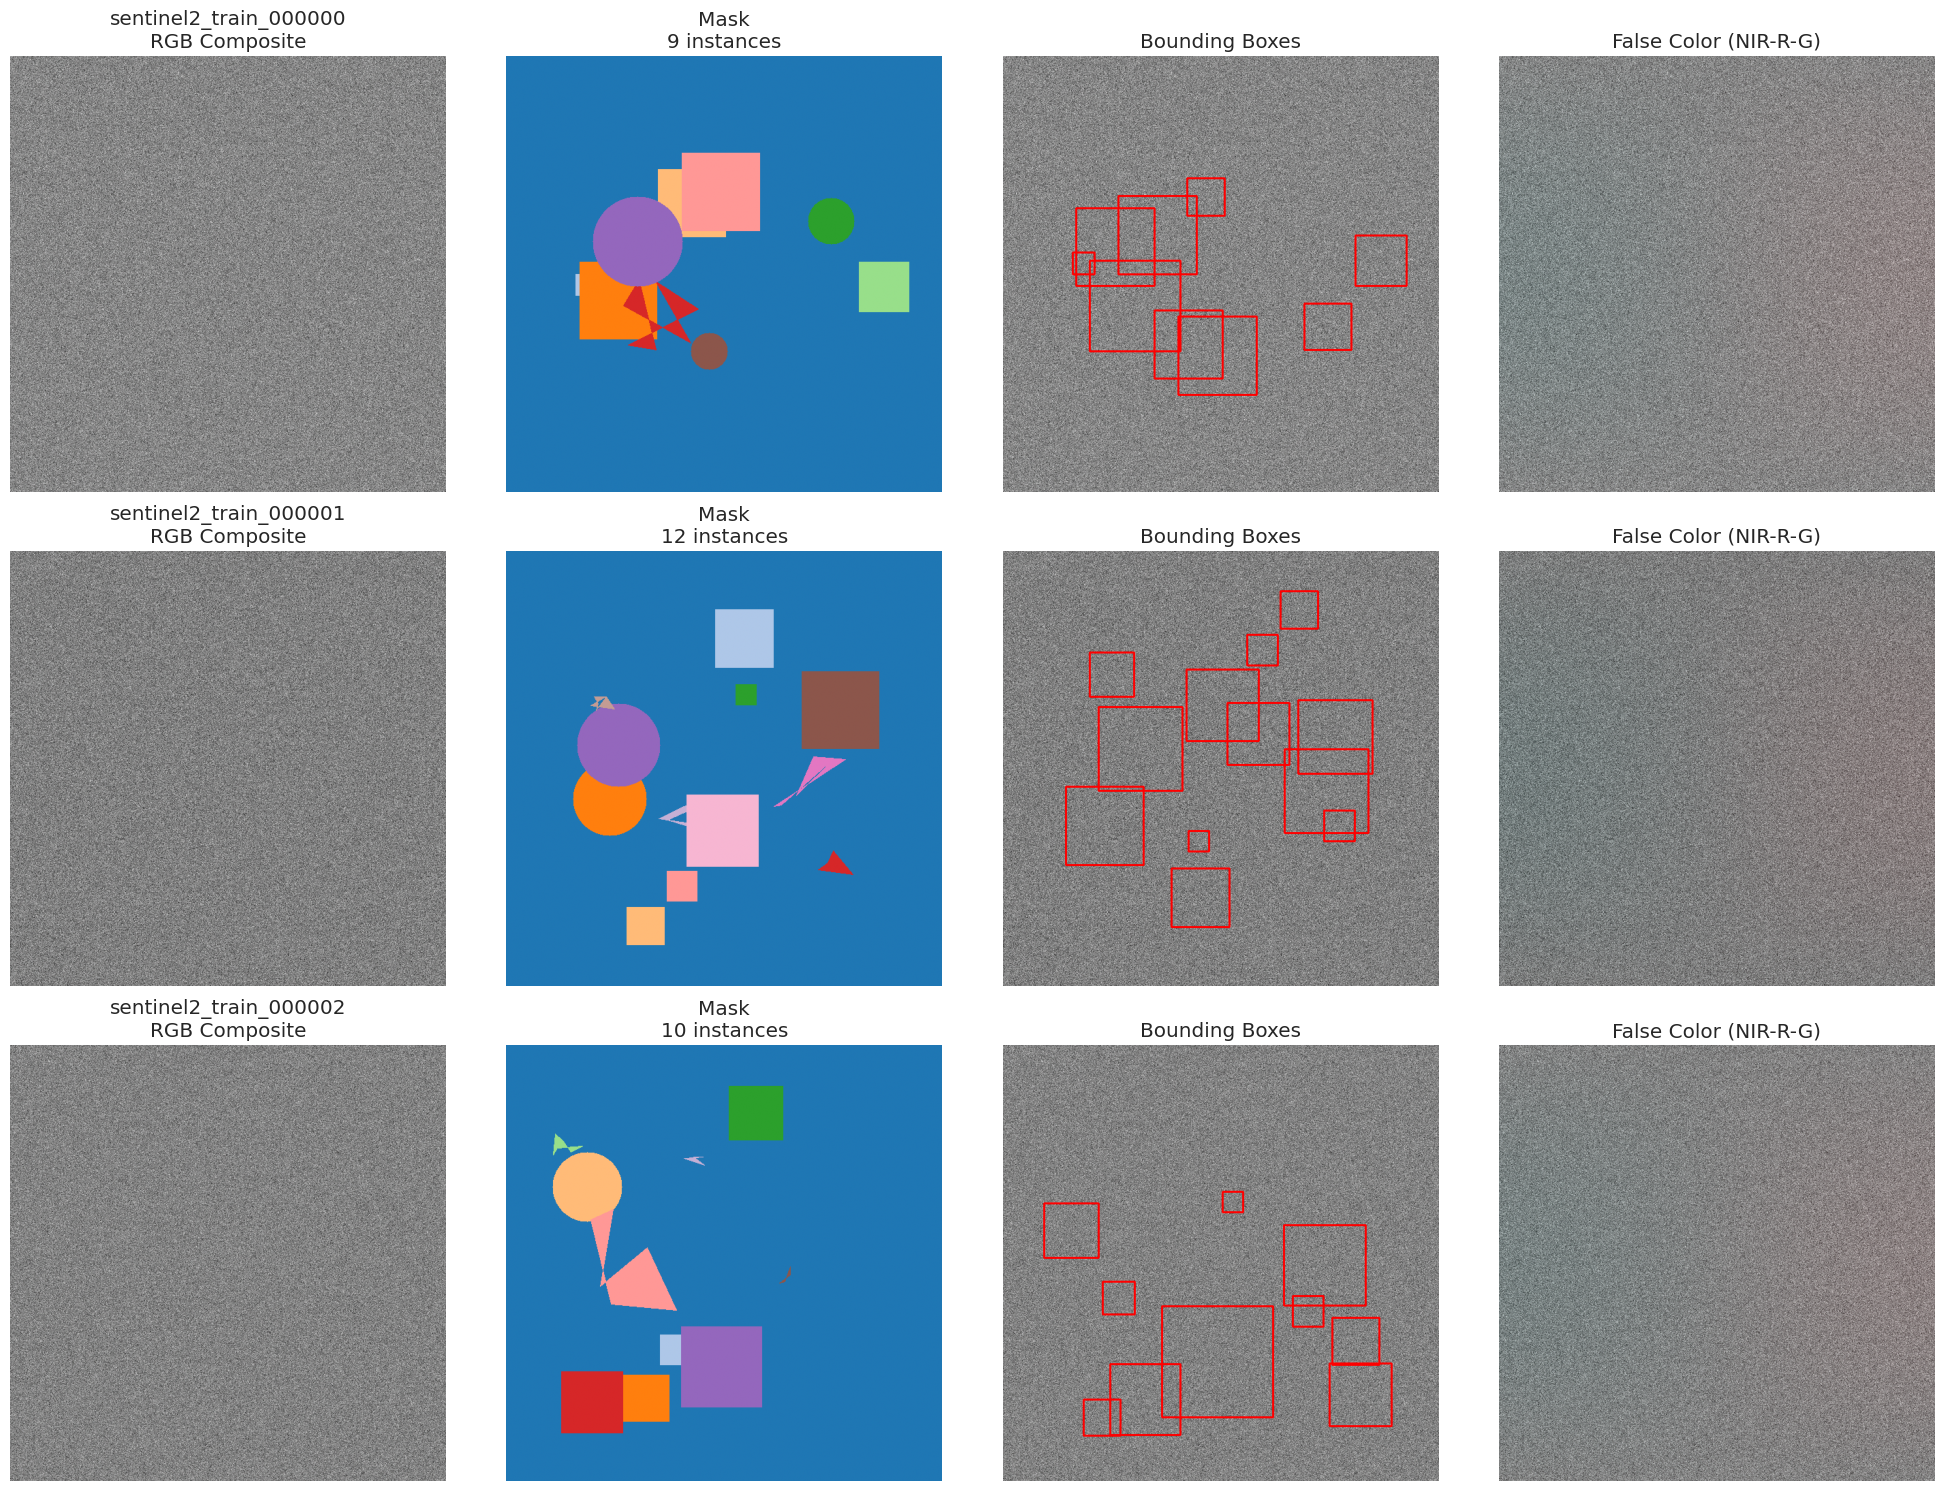

Analisando amostras:   0%|          | 0/100 [00:00<?, ?it/s]

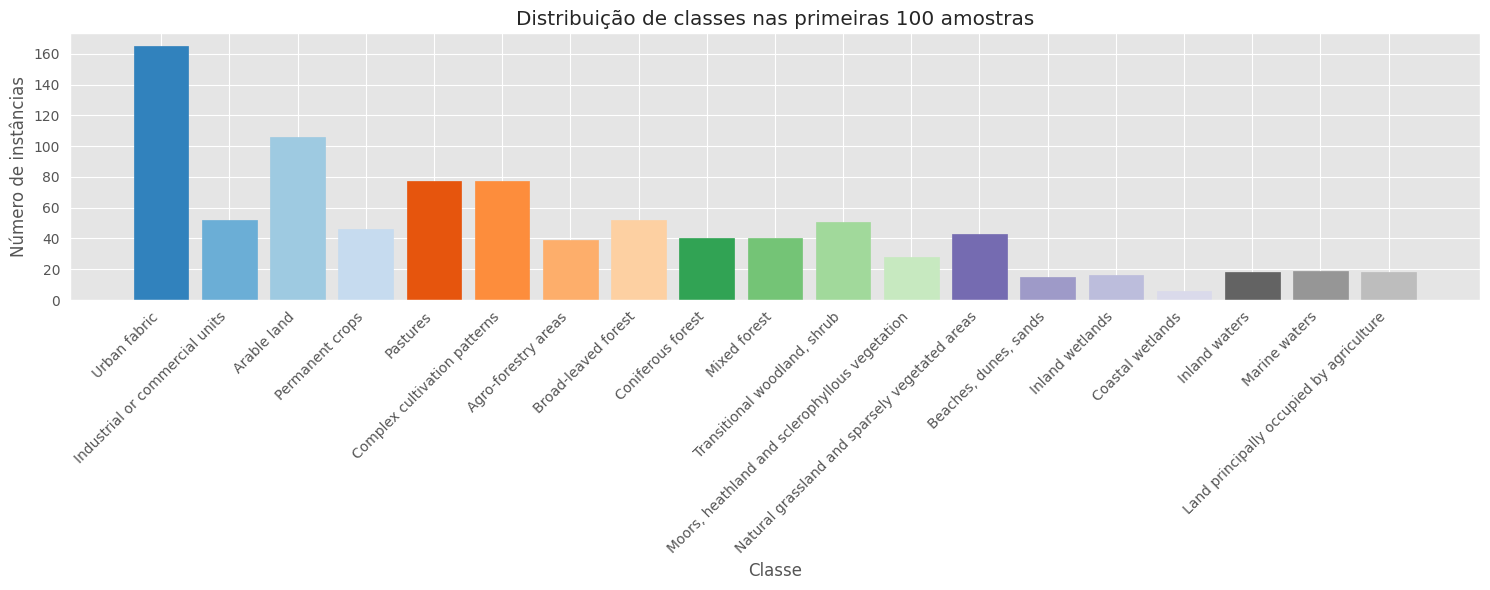

In [ ]:
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class Sentinel2YOLODataset(Dataset):
    def __init__(self, num_samples=200, img_size=640, mode='train', augment=False):
        self.img_size = img_size
        self.num_samples = num_samples
        self.mode = mode
        self.augment = augment and mode == 'train'
        self.num_classes = NUM_CLASSES

        self.transform = self._get_transforms()

    def _get_transforms(self):
        if self.augment:
            return A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.HueSaturationValue(p=0.3),
                A.GaussNoise(p=0.2),
                A.CLAHE(p=0.2),
                A.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='yolo',
                                       label_fields=['class_labels']))
        else:
            return A.Compose([
                A.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], bbox_params=A.BboxParams(format='yolo',
                                       label_fields=['class_labels']))

    def _simulate_sentinel2_bands(self):
        bands = {}

        base_noise = np.random.randn(self.img_size, self.img_size)

        bands['B02'] = self._create_spectral_band(base_noise, wavelength=0.483)
        bands['B03'] = self._create_spectral_band(base_noise, wavelength=0.560)
        bands['B04'] = self._create_spectral_band(base_noise, wavelength=0.665)
        bands['B08'] = self._create_spectral_band(base_noise, wavelength=0.842, is_nir=True)

        wavelengths = [0.705, 0.740, 0.783, 0.865, 1.610, 2.190]
        band_names = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']

        for wavelength, band_name in zip(wavelengths, band_names):
            bands[band_name] = self._create_lower_res_band(wavelength)

        return bands

    def _create_spectral_band(self, base, wavelength, is_nir=False):
        band = base.copy()

        if is_nir:
            x = np.linspace(-5, 5, self.img_size)
            y = np.linspace(-5, 5, self.img_size)
            X, Y = np.meshgrid(x, y)
            vegetation_pattern = 0.4 * np.sin(X * 0.3) * np.cos(Y * 0.3)
            band += vegetation_pattern

        wavelength_factor = wavelength * 0.5
        band += wavelength_factor * np.random.randn(self.img_size, self.img_size) * 0.1

        band = (band - band.mean()) / (band.std() + 1e-8)

        return band

    def _create_lower_res_band(self, wavelength):
        low_res_size = self.img_size // 2

        base_noise = np.random.randn(low_res_size, low_res_size)

        band = base_noise.copy()

        x = np.linspace(-5, 5, low_res_size)
        y = np.linspace(-5, 5, low_res_size)
        X, Y = np.meshgrid(x, y)

        spectral_pattern = 0.3 * np.sin(X * 0.4 + wavelength * 10) * np.cos(Y * 0.4 + wavelength * 10)
        band += spectral_pattern

        wavelength_factor = wavelength * 0.5
        band += wavelength_factor * np.random.randn(low_res_size, low_res_size) * 0.1

        band = (band - band.mean()) / (band.std() + 1e-8)

        band = cv2.resize(band, (self.img_size, self.img_size))

        return band

    def _create_rgb_composite(self, bands):
        rgb = np.stack([
            bands['B04'],
            bands['B03'],
            bands['B02']
        ], axis=2)

        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        rgb = (rgb * 255).astype(np.uint8)

        return rgb

    def _create_false_color_composite(self, bands):
        false_color = np.stack([
            bands['B08'],
            bands['B04'],
            bands['B03']
        ], axis=2)

        false_color = (false_color - false_color.min()) / (false_color.max() - false_color.min() + 1e-8)
        false_color = (false_color * 255).astype(np.uint8)

        return false_color

    def _create_landcover_instances(self):
        mask = np.zeros((self.img_size, self.img_size), dtype=np.int32)
        polygons = []
        bboxes = []
        class_ids = []

        if self.mode == 'train':
            num_instances = np.random.randint(5, 15)
        else:
            num_instances = np.random.randint(3, 10)

        for inst_id in range(num_instances):
            class_probs = np.array([0.15, 0.08, 0.12, 0.05, 0.08, 0.07, 0.04, 0.06, 0.05,
                          0.04, 0.05, 0.03, 0.04, 0.01, 0.02, 0.01, 0.02, 0.02, 0.02])

            class_probs = class_probs / class_probs.sum()

            class_id = np.random.choice(self.num_classes, p=class_probs)

            if class_id == 0:
                min_size, max_size = 20, 60
            elif class_id in [7, 8, 9]:
                min_size, max_size = 80, 180
            elif class_id in [16, 17]:
                min_size, max_size = 50, 150
            else:
                min_size, max_size = 40, 120

            size = np.random.randint(min_size, max_size)

            margin = size // 2 + 10
            x_min = np.random.randint(margin, self.img_size - size - margin)
            y_min = np.random.randint(margin, self.img_size - size - margin)
            x_max = x_min + size
            y_max = y_min + size

            shape_type = self._get_shape_for_class(class_id)

            instance_mask = self._create_instance_shape(shape_type, x_min, y_min, x_max, y_max)

            overlap_area = np.sum((mask > 0) & (instance_mask == 1))
            if overlap_area / np.sum(instance_mask) > 0.7:
                continue

            instance_id = inst_id + 1
            mask[instance_mask == 1] = instance_id

            polygon = self._mask_to_polygon(instance_mask, x_min, y_min, x_max, y_max)

            if polygon is not None:
                polygons.append(polygon)
                bboxes.append([x_min, y_min, x_max, y_max])
                class_ids.append(class_id)

        return mask, polygons, bboxes, class_ids

    def _get_shape_for_class(self, class_id):
        if class_id == 0:
            return np.random.choice(['rectangle', 'polygon'], p=[0.7, 0.3])
        elif class_id in [1, 2, 3, 4, 5, 6]:
            return np.random.choice(['rectangle', 'polygon', 'circle'], p=[0.6, 0.3, 0.1])
        elif class_id in [7, 8, 9, 10]:
            return np.random.choice(['polygon', 'circle'], p=[0.8, 0.2])
        elif class_id in [16, 17]:
            return np.random.choice(['polygon', 'circle'], p=[0.5, 0.5])
        else:
            return np.random.choice(['polygon', 'rectangle', 'circle'], p=[0.4, 0.4, 0.2])

    def _create_instance_shape(self, shape_type, x_min, y_min, x_max, y_max):
        instance_mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)

        if shape_type == 'rectangle':
            instance_mask[y_min:y_max, x_min:x_max] = 1

        elif shape_type == 'circle':
            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2
            radius = min(x_max - x_min, y_max - y_min) // 2

            y_coords, x_coords = np.ogrid[:self.img_size, :self.img_size]
            distance = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)
            instance_mask[distance <= radius] = 1

        elif shape_type == 'polygon':
            num_vertices = np.random.randint(4, 8)
            vertices = []

            for _ in range(num_vertices):
                vx = np.random.randint(x_min, x_max)
                vy = np.random.randint(y_min, y_max)
                vertices.append([vx, vy])

            vertices = np.array(vertices, dtype=np.int32)
            cv2.fillPoly(instance_mask, [vertices], 1)

        return instance_mask

    def _mask_to_polygon(self, mask, x_min, y_min, x_max, y_max):
        roi = mask[y_min:y_max, x_min:x_max]

        if np.sum(roi) == 0:
            return None

        contours, _ = cv2.findContours(roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            return None

        contour = max(contours, key=cv2.contourArea)

        epsilon = 0.005 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) < 3:
            return None

        polygon = approx.flatten().astype(np.float32)

        polygon[0::2] = (polygon[0::2] + x_min) / self.img_size
        polygon[1::2] = (polygon[1::2] + y_min) / self.img_size

        return polygon.tolist()

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        seed = idx + (1000 if self.mode == 'val' else 2000 if self.mode == 'test' else 0)
        np.random.seed(seed)
        random.seed(seed)

        bands = self._simulate_sentinel2_bands()

        rgb_image = self._create_rgb_composite(bands)

        mask, polygons, bboxes, class_ids = self._create_landcover_instances()

        image_for_aug = rgb_image.copy()
        bboxes_for_aug = []

        for i, bbox in enumerate(bboxes):
            x_min, y_min, x_max, y_max = bbox
            x_center = ((x_min + x_max) / 2) / self.img_size
            y_center = ((y_min + y_max) / 2) / self.img_size
            width = (x_max - x_min) / self.img_size
            height = (y_max - y_min) / self.img_size

            bboxes_for_aug.append([x_center, y_center, width, height])

        if self.augment and len(bboxes_for_aug) > 0:
            augmented = self.transform(
                image=image_for_aug,
                bboxes=bboxes_for_aug,
                class_labels=class_ids
            )
            image = augmented['image']
            bboxes_aug = augmented['bboxes']
            class_ids_aug = augmented['class_labels']

            bboxes_final = []
            polygons_final = []

            for i, bbox in enumerate(bboxes_aug):
                x_center, y_center, width, height = bbox
                x_center_abs = x_center * self.img_size
                y_center_abs = y_center * self.img_size
                width_abs = width * self.img_size
                height_abs = height * self.img_size

                x_min = int(x_center_abs - width_abs / 2)
                y_min = int(y_center_abs - height_abs / 2)
                x_max = int(x_center_abs + width_abs / 2)
                y_max = int(y_center_abs + height_abs / 2)

                bboxes_final.append([x_min, y_min, x_max, y_max])

                if i < len(polygons):
                    polygons_final.append(polygons[i])

            bboxes = bboxes_final
            polygons = polygons_final
            class_ids = class_ids_aug

        else:
            transformed = self.transform(image=image_for_aug)
            image = transformed['image']

        yolo_labels = []
        for i, (class_id, polygon) in enumerate(zip(class_ids, polygons)):
            if polygon and len(polygon) >= 6:
                label_line = f"{class_id} " + " ".join(map(str, polygon))
                yolo_labels.append(label_line)

        return {
            'image': image,
            'rgb_original': rgb_image,
            'mask': mask,
            'yolo_labels': yolo_labels,
            'bboxes': bboxes,
            'class_ids': class_ids,
            'polygons': polygons,
            'image_id': f'sentinel2_{self.mode}_{idx:06d}',
            'bands': {k: v for k, v in bands.items()}
        }

    def visualize_sample(self, idx=0, num_samples=3):
        fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))

        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for sample_idx in range(num_samples):
            actual_idx = min(idx + sample_idx, len(self) - 1)
            sample = self.__getitem__(actual_idx)

            rgb = sample['rgb_original']
            axes[sample_idx, 0].imshow(rgb)
            axes[sample_idx, 0].set_title(f'{sample["image_id"]}\nRGB Composite')
            axes[sample_idx, 0].axis('off')

            mask = sample['mask']
            unique_ids = np.unique(mask)
            num_instances = len(unique_ids) - 1 if 0 in unique_ids else len(unique_ids)

            axes[sample_idx, 1].imshow(mask, cmap='tab20', vmin=0, vmax=19)
            axes[sample_idx, 1].set_title(f'Mask\n{num_instances} instances')
            axes[sample_idx, 1].axis('off')

            rgb_with_boxes = rgb.copy()
            for bbox in sample['bboxes']:
                x_min, y_min, x_max, y_max = bbox
                cv2.rectangle(rgb_with_boxes, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

            axes[sample_idx, 2].imshow(rgb_with_boxes)
            axes[sample_idx, 2].set_title('Bounding Boxes')
            axes[sample_idx, 2].axis('off')

            false_color = self._create_false_color_composite(sample['bands'])
            axes[sample_idx, 3].imshow(false_color)
            axes[sample_idx, 3].set_title('False Color (NIR-R-G)')
            axes[sample_idx, 3].axis('off')

        plt.tight_layout()
        plt.show()

        return sample if num_samples == 1 else None

train_dataset = Sentinel2YOLODataset(num_samples=500, mode='train', augment=True)
val_dataset = Sentinel2YOLODataset(num_samples=100, mode='val', augment=False)
test_dataset = Sentinel2YOLODataset(num_samples=100, mode='test', augment=False)

train_dataset.visualize_sample(num_samples=3)

all_class_ids = []
for i in tqdm(range(min(100, len(train_dataset))), desc="Analisando amostras"):
    sample = train_dataset[i]
    all_class_ids.extend(sample['class_ids'])

unique, counts = np.unique(all_class_ids, return_counts=True)

unique = unique.astype(int)

plt.figure(figsize=(15, 6))
bars = plt.bar(range(len(class_dist)), counts)
plt.xlabel('Classe')
plt.ylabel('Número de instâncias')
plt.title('Distribuição de classes nas primeiras 100 amostras')

plt.xticks(range(len(class_dist)), [CLASS_NAMES[i] for i in unique], rotation=45, ha='right')

for bar, class_id in zip(bars, unique):
    bar.set_color(COLORS[class_id % len(COLORS)])

plt.tight_layout()
plt.show()

Salvando train:   0%|          | 0/400 [00:00<?, ?it/s]

Salvando val:   0%|          | 0/80 [00:00<?, ?it/s]

Salvando test:   0%|          | 0/80 [00:00<?, ?it/s]

Analisando labels train:   0%|          | 0/100 [00:00<?, ?it/s]

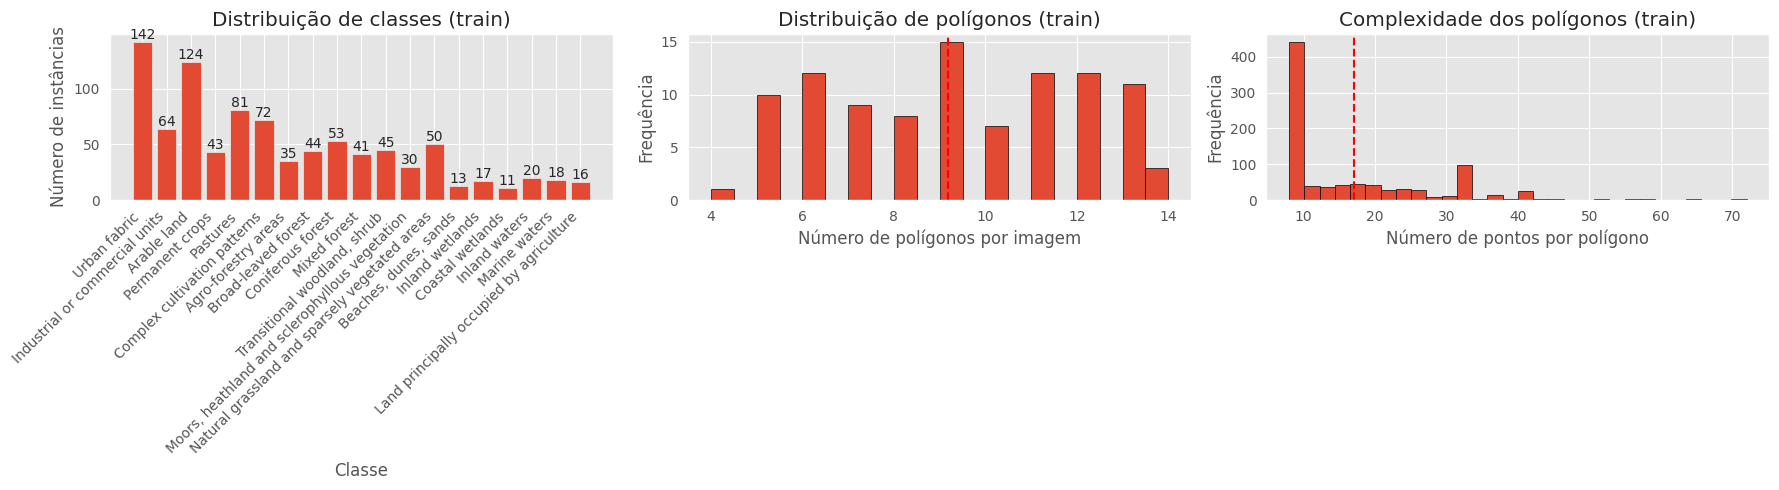

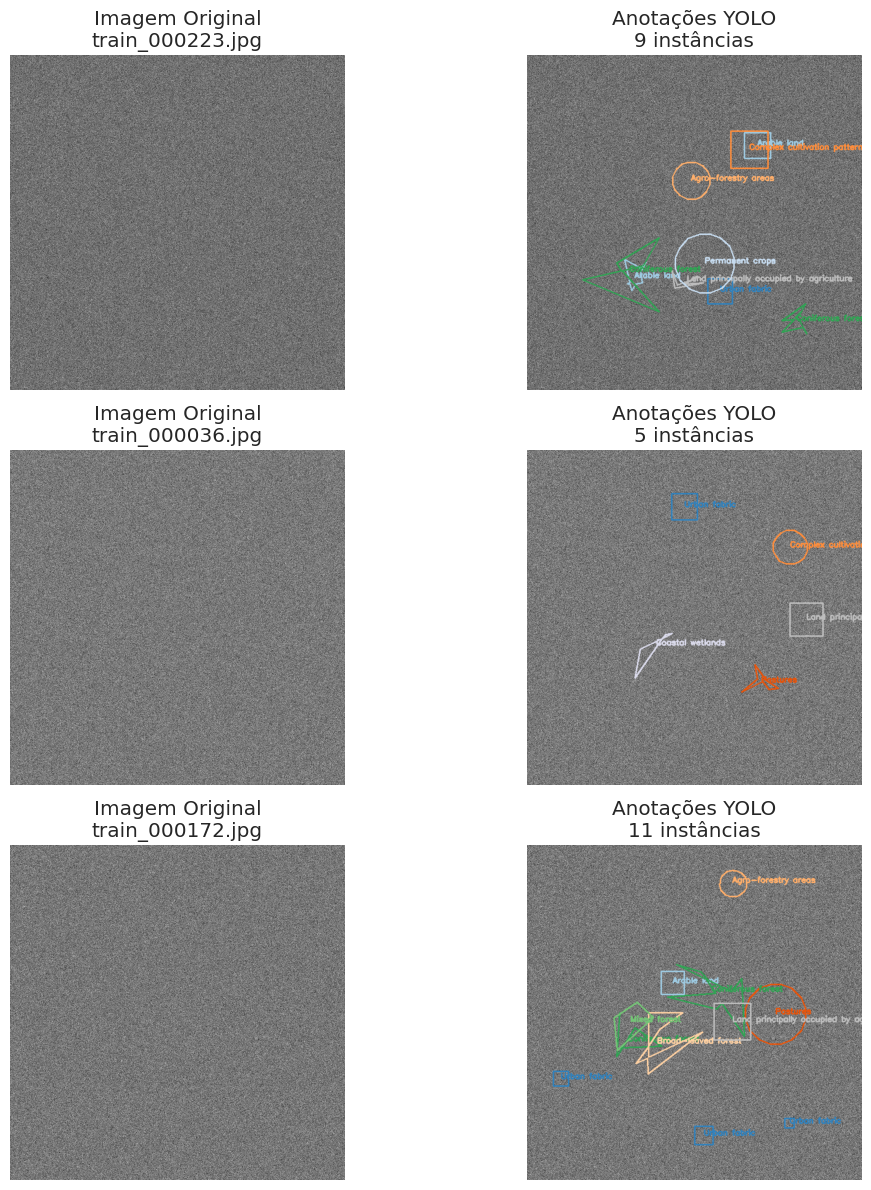

True

In [ ]:
import yaml
import json
import shutil
from pathlib import Path

def prepare_yolo_dataset_structure():
    base_dir = Path('yolo_sentinel2_dataset')

    directories = [
        'images/train',
        'images/val',
        'images/test',
        'labels/train',
        'labels/val',
        'labels/test'
    ]

    for dir_path in directories:
        (base_dir / dir_path).mkdir(parents=True, exist_ok=True)

    return base_dir

def create_yolo_config():
    config = {
        'path': '/content/yolo_sentinel2_dataset',
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': NUM_CLASSES,
        'names': CLASS_NAMES
    }

    config_path = Path('yolo_sentinel2_dataset') / 'dataset.yaml'
    with open(config_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False)

    return config_path

class SimpleSentinel2YOLODataset(Dataset):
    def __init__(self, num_samples=200, img_size=640, mode='train'):
        self.img_size = img_size
        self.num_samples = num_samples
        self.mode = mode
        self.num_classes = NUM_CLASSES

    def _simulate_sentinel2_bands(self):
        bands = {}

        base_noise = np.random.randn(self.img_size, self.img_size)

        bands['B02'] = self._create_spectral_band(base_noise, wavelength=0.483)
        bands['B03'] = self._create_spectral_band(base_noise, wavelength=0.560)
        bands['B04'] = self._create_spectral_band(base_noise, wavelength=0.665)
        bands['B08'] = self._create_spectral_band(base_noise, wavelength=0.842, is_nir=True)

        wavelengths = [0.705, 0.740, 0.783, 0.865, 1.610, 2.190]
        band_names = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']

        for wavelength, band_name in zip(wavelengths, band_names):
            bands[band_name] = self._create_lower_res_band(wavelength)

        return bands

    def _create_spectral_band(self, base, wavelength, is_nir=False):
        band = base.copy()

        if is_nir:
            x = np.linspace(-5, 5, self.img_size)
            y = np.linspace(-5, 5, self.img_size)
            X, Y = np.meshgrid(x, y)
            vegetation_pattern = 0.4 * np.sin(X * 0.3) * np.cos(Y * 0.3)
            band += vegetation_pattern

        wavelength_factor = wavelength * 0.5
        band += wavelength_factor * np.random.randn(self.img_size, self.img_size) * 0.1

        band = (band - band.mean()) / (band.std() + 1e-8)

        return band

    def _create_lower_res_band(self, wavelength):
        low_res_size = self.img_size // 2

        base_noise = np.random.randn(low_res_size, low_res_size)

        band = base_noise.copy()

        x = np.linspace(-5, 5, low_res_size)
        y = np.linspace(-5, 5, low_res_size)
        X, Y = np.meshgrid(x, y)

        spectral_pattern = 0.3 * np.sin(X * 0.4 + wavelength * 10) * np.cos(Y * 0.4 + wavelength * 10)
        band += spectral_pattern

        wavelength_factor = wavelength * 0.5
        band += wavelength_factor * np.random.randn(low_res_size, low_res_size) * 0.1

        band = (band - band.mean()) / (band.std() + 1e-8)

        band = cv2.resize(band, (self.img_size, self.img_size))

        return band

    def _create_rgb_composite(self, bands):
        rgb = np.stack([
            bands['B04'],
            bands['B03'],
            bands['B02']
        ], axis=2)

        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        rgb = (rgb * 255).astype(np.uint8)

        return rgb

    def _create_false_color_composite(self, bands):
        false_color = np.stack([
            bands['B08'],
            bands['B04'],
            bands['B03']
        ], axis=2)

        false_color = (false_color - false_color.min()) / (false_color.max() - false_color.min() + 1e-8)
        false_color = (false_color * 255).astype(np.uint8)

        return false_color

    def _create_landcover_instances(self):
        mask = np.zeros((self.img_size, self.img_size), dtype=np.int32)
        polygons = []
        bboxes = []
        class_ids = []

        if self.mode == 'train':
            num_instances = np.random.randint(5, 15)
        else:
            num_instances = np.random.randint(3, 10)

        for inst_id in range(num_instances):
            class_probs = np.array([0.15, 0.08, 0.12, 0.05, 0.08, 0.07, 0.04, 0.06, 0.05,
                          0.04, 0.05, 0.03, 0.04, 0.01, 0.02, 0.01, 0.02, 0.02, 0.02])

            class_probs = class_probs / class_probs.sum()

            class_id = np.random.choice(self.num_classes, p=class_probs)

            if class_id == 0:
                min_size, max_size = 20, 60
            elif class_id in [7, 8, 9]:
                min_size, max_size = 80, 180
            elif class_id in [16, 17]:
                min_size, max_size = 50, 150
            else:
                min_size, max_size = 40, 120

            size = np.random.randint(min_size, max_size)

            margin = size // 2 + 10
            x_min = np.random.randint(margin, self.img_size - size - margin)
            y_min = np.random.randint(margin, self.img_size - size - margin)
            x_max = x_min + size
            y_max = y_min + size

            shape_type = self._get_shape_for_class(class_id)

            instance_mask = self._create_instance_shape(shape_type, x_min, y_min, x_max, y_max)

            overlap_area = np.sum((mask > 0) & (instance_mask == 1))
            if overlap_area / np.sum(instance_mask) > 0.7:
                continue

            instance_id = inst_id + 1
            mask[instance_mask == 1] = instance_id

            polygon = self._mask_to_polygon(instance_mask, x_min, y_min, x_max, y_max)

            if polygon is not None:
                polygons.append(polygon)
                bboxes.append([x_min, y_min, x_max, y_max])
                class_ids.append(class_id)

        return mask, polygons, bboxes, class_ids

    def _get_shape_for_class(self, class_id):
        if class_id == 0:
            return np.random.choice(['rectangle', 'polygon'], p=[0.7, 0.3])
        elif class_id in [1, 2, 3, 4, 5, 6]:
            return np.random.choice(['rectangle', 'polygon', 'circle'], p=[0.6, 0.3, 0.1])
        elif class_id in [7, 8, 9, 10]:
            return np.random.choice(['polygon', 'circle'], p=[0.8, 0.2])
        elif class_id in [16, 17]:
            return np.random.choice(['polygon', 'circle'], p=[0.5, 0.5])
        else:
            return np.random.choice(['polygon', 'rectangle', 'circle'], p=[0.4, 0.4, 0.2])

    def _create_instance_shape(self, shape_type, x_min, y_min, x_max, y_max):
        instance_mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)

        if shape_type == 'rectangle':
            instance_mask[y_min:y_max, x_min:x_max] = 1

        elif shape_type == 'circle':
            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2
            radius = min(x_max - x_min, y_max - y_min) // 2

            y_coords, x_coords = np.ogrid[:self.img_size, :self.img_size]
            distance = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)
            instance_mask[distance <= radius] = 1

        elif shape_type == 'polygon':
            num_vertices = np.random.randint(4, 8)
            vertices = []

            for _ in range(num_vertices):
                vx = np.random.randint(x_min, x_max)
                vy = np.random.randint(y_min, y_max)
                vertices.append([vx, vy])

            vertices = np.array(vertices, dtype=np.int32)
            cv2.fillPoly(instance_mask, [vertices], 1)

        return instance_mask

    def _mask_to_polygon(self, mask, x_min, y_min, x_max, y_max):
        roi = mask[y_min:y_max, x_min:x_max]

        if np.sum(roi) == 0:
            return None

        contours, _ = cv2.findContours(roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            return None

        contour = max(contours, key=cv2.contourArea)

        epsilon = 0.005 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) < 3:
            return None

        polygon = approx.flatten().astype(np.float32)

        polygon[0::2] = (polygon[0::2] + x_min) / self.img_size
        polygon[1::2] = (polygon[1::2] + y_min) / self.img_size

        return polygon.tolist()

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        seed = idx + (1000 if self.mode == 'val' else 2000 if self.mode == 'test' else 0)
        np.random.seed(seed)
        random.seed(seed)

        bands = self._simulate_sentinel2_bands()

        rgb_image = self._create_rgb_composite(bands)

        mask, polygons, bboxes, class_ids = self._create_landcover_instances()

        yolo_labels = []
        for i, (class_id, polygon) in enumerate(zip(class_ids, polygons)):
            if polygon and len(polygon) >= 6:
                label_line = f"{class_id} " + " ".join(map(str, polygon))
                yolo_labels.append(label_line)

        return {
            'image': rgb_image,
            'yolo_labels': yolo_labels,
            'bboxes': bboxes,
            'class_ids': class_ids,
            'polygons': polygons,
            'image_id': f'sentinel2_{self.mode}_{idx:06d}',
        }

def save_yolo_dataset_simple(dataset, split_name, base_dir, max_samples=None):
    base_dir = Path(base_dir)

    if max_samples:
        dataset_size = min(max_samples, len(dataset))
    else:
        dataset_size = len(dataset)

    for idx in tqdm(range(dataset_size), desc=f"Salvando {split_name}"):
        sample = dataset[idx]

        image = sample['image']

        img_path = base_dir / 'images' / split_name / f'{split_name}_{idx:06d}.jpg'
        Image.fromarray(image).save(img_path)

        label_path = base_dir / 'labels' / split_name / f'{split_name}_{idx:06d}.txt'

        with open(label_path, 'w') as f:
            for label_line in sample['yolo_labels']:
                f.write(label_line + '\n')

base_dir = prepare_yolo_dataset_structure()

simple_train_dataset = SimpleSentinel2YOLODataset(num_samples=400, mode='train')
simple_val_dataset = SimpleSentinel2YOLODataset(num_samples=80, mode='val')
simple_test_dataset = SimpleSentinel2YOLODataset(num_samples=80, mode='test')

save_yolo_dataset_simple(simple_train_dataset, 'train', base_dir)
save_yolo_dataset_simple(simple_val_dataset, 'val', base_dir)
save_yolo_dataset_simple(simple_test_dataset, 'test', base_dir)

config_path = create_yolo_config()

with open(config_path, 'r') as f:
    config_content = f.read()

def analyze_yolo_labels(dataset_split='train'):
    label_dir = base_dir / 'labels' / dataset_split
    label_files = list(label_dir.glob('*.txt'))

    if not label_files:
        return

    all_class_ids = []
    num_polygons_list = []
    polygon_lengths = []

    for label_file in tqdm(label_files[:100], desc=f"Analisando labels {dataset_split}"):
        with open(label_file, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = int(parts[0])
                all_class_ids.append(class_id)

                polygon_points = len(parts[1:])
                polygon_lengths.append(polygon_points)

        num_polygons_list.append(len(lines))

    if all_class_ids:
        unique_classes, class_counts = np.unique(all_class_ids, return_counts=True)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        unique_classes = unique_classes.astype(int)

        axes[0].bar(range(len(unique_classes)), class_counts)
        axes[0].set_xlabel('Classe')
        axes[0].set_ylabel('Número de instâncias')
        axes[0].set_title(f'Distribuição de classes ({dataset_split})')
        axes[0].set_xticks(range(len(unique_classes)))
        axes[0].set_xticklabels([CLASS_NAMES[i] for i in unique_classes], rotation=45, ha='right')

        for i, count in enumerate(class_counts):
            axes[0].text(i, count, str(count), ha='center', va='bottom')

        axes[1].hist(num_polygons_list, bins=20, edgecolor='black')
        axes[1].set_xlabel('Número de polígonos por imagem')
        axes[1].set_ylabel('Frequência')
        axes[1].set_title(f'Distribuição de polígonos ({dataset_split})')
        axes[1].axvline(np.mean(num_polygons_list), color='red', linestyle='--')

        axes[2].hist(polygon_lengths, bins=30, edgecolor='black')
        axes[2].set_xlabel('Número de pontos por polígono')
        axes[2].set_ylabel('Frequência')
        axes[2].set_title(f'Complexidade dos polígonos ({dataset_split})')
        axes[2].axvline(np.mean(polygon_lengths), color='red', linestyle='--')

        plt.tight_layout()
        plt.show()

analyze_yolo_labels('train')

def visualize_yolo_annotations(split='train', num_samples=3):
    img_dir = base_dir / 'images' / split
    label_dir = base_dir / 'labels' / split

    img_files = list(img_dir.glob('*.jpg'))

    if not img_files:
        return

    selected_files = img_files[:num_samples]

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for idx, img_file in enumerate(selected_files):
        img = cv2.imread(str(img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        label_file = label_dir / f'{img_file.stem}.txt'

        img_with_annotations = img.copy()

        if label_file.exists():
            with open(label_file, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) > 6:
                    class_id = int(parts[0])
                    polygon_points = list(map(float, parts[1:]))

                    polygon = []
                    for i in range(0, len(polygon_points), 2):
                        x = int(polygon_points[i] * img.shape[1])
                        y = int(polygon_points[i+1] * img.shape[0])
                        polygon.append([x, y])

                    polygon = np.array(polygon, dtype=np.int32)

                    color = (int(COLORS[class_id % len(COLORS)][0]*255),
                            int(COLORS[class_id % len(COLORS)][1]*255),
                            int(COLORS[class_id % len(COLORS)][2]*255))

                    cv2.polylines(img_with_annotations, [polygon], True, color, 2)

                    if len(polygon) > 0:
                        centroid = polygon.mean(axis=0).astype(int)
                        cv2.putText(img_with_annotations, CLASS_NAMES[class_id],
                                  (centroid[0], centroid[1]),
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f'Imagem Original\n{img_file.name}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(img_with_annotations)
        axes[idx, 1].set_title(f'Anotações YOLO\n{len(lines) if label_file.exists() else 0} instâncias')
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_yolo_annotations('train', num_samples=3)

def verify_dataset_integrity():
    issues = []

    for split in ['train', 'val', 'test']:
        img_dir = base_dir / 'images' / split
        label_dir = base_dir / 'labels' / split

        img_files = sorted(img_dir.glob('*.jpg'))
        label_files = sorted(label_dir.glob('*.txt'))

        img_names = {f.stem for f in img_files}
        label_names = {f.stem for f in label_files}

        if len(img_files) != len(label_files):
            issues.append(f"{split}: Número de imagens ({len(img_files)}) diferente de labels ({len(label_files)})")

        missing_labels = img_names - label_names
        if missing_labels:
            issues.append(f"{split}: Labels faltando para imagens: {list(missing_labels)[:3]}...")

        extra_labels = label_names - img_names
        if extra_labels:
            issues.append(f"{split}: Imagens faltando para labels: {list(extra_labels)[:3]}...")

    if issues:
        return False
    else:
        return True

verify_dataset_integrity()

In [ ]:
import torch
from ultralytics import YOLO
import time
from datetime import datetime

def train_yolo_model():
    model = YOLO('yolo11n-seg.pt')

    project_name = f"yolo_sentinel2_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

    results = model.train(
        data=str(config_path),
        epochs=20,
        imgsz=640,
        batch=8,
        patience=5,
        save=True,
        save_period=5,
        device='0' if torch.cuda.is_available() else 'cpu',
        workers=2,
        project='runs',
        name=project_name,
        exist_ok=True,
        pretrained=True,
        optimizer='SGD',
        lr0=0.01,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=2,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,
        box=7.5,
        cls=0.5,
        dfl=1.5,
        overlap_mask=True,
        mask_ratio=4,
        dropout=0.0,
        val=True,
        plots=True
    )

    return model, results

try:
    model, results = train_yolo_model()

    best_model_path = f'runs/segment/train/weights/best.pt'

except Exception as e:
    try:
        model = YOLO('yolo11n-seg.pt')

        results = model.train(
            data=str(config_path),
            epochs=15,
            imgsz=640,
            batch=4,
            device='0' if torch.cuda.is_available() else 'cpu',
            workers=1,
            project='runs',
            name='yolo_sentinel2_simple',
            exist_ok=True
        )

        best_model_path = f'runs/segment/yolo_sentinel2_simple/weights/best.pt'

    except Exception as e2:
        best_model_path = None

def visualize_training_results():
    try:
        results_dir = Path('runs/segment/train')

        if not results_dir.exists():
            results_dir = Path('runs/segment/yolo_sentinel2_simple')

        if results_dir.exists():
            results_dir = results_dir.resolve()

            fig, axes = plt.subplots(2, 3, figsize=(18, 10))

            metrics_files = list(results_dir.glob('*metrics*.png'))
            curves_files = list(results_dir.glob('*curves*.png'))
            results_files = list(results_dir.glob('*results*.png'))
            confusion_files = list(results_dir.glob('*confusion*.png'))
            labels_files = list(results_dir.glob('*labels*.jpg'))
            val_batch_files = list(results_dir.glob('*val_batch*.jpg'))

            if metrics_files:
                img = cv2.imread(str(metrics_files[0]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[0, 0].imshow(img)
                axes[0, 0].axis('off')
                axes[0, 0].set_title('Métricas de Treinamento')

            if curves_files:
                img = cv2.imread(str(curves_files[0]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[0, 1].imshow(img)
                axes[0, 1].axis('off')
                axes[0, 1].set_title('Curvas de Aprendizado')

            if results_files:
                img = cv2.imread(str(results_files[0]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[0, 2].imshow(img)
                axes[0, 2].axis('off')
                axes[0, 2].set_title('Resultados do Modelo')

            if confusion_files:
                img = cv2.imread(str(confusion_files[0]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[1, 0].imshow(img)
                axes[1, 0].axis('off')
                axes[1, 0].set_title('Matriz de Confusão')

            if labels_files:
                img = cv2.imread(str(labels_files[0]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[1, 1].imshow(img)
                axes[1, 1].axis('off')
                axes[1, 1].set_title('Distribuição de Labels')

            if val_batch_files:
                img = cv2.imread(str(val_batch_files[0]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[1, 2].imshow(img)
                axes[1, 2].axis('off')
                axes[1, 2].set_title('Batch de Validação')

            plt.tight_layout()
            plt.show()

            return True

    except Exception as e:
        return False

if 'best_model_path' in locals() and best_model_path:
    try:
        best_model = YOLO(best_model_path)
    except Exception as e:
        best_model = None
else:
    try:
        best_model = YOLO('yolo11n-seg.pt')
    except:
        best_model = None

visualize_training_results()

def evaluate_model_on_test_set():
    if best_model is None:
        return None

    try:
        test_results = best_model.val(
            data=str(config_path),
            split='test',
            imgsz=640,
            batch=8,
            conf=0.25,
            iou=0.6,
            device='0' if torch.cuda.is_available() else 'cpu',
            plots=True
        )

        return test_results

    except Exception as e:
        return None

test_results = evaluate_model_on_test_set()

def predict_on_sample_images(num_samples=3):
    if best_model is None:
        return

    test_images_dir = base_dir / 'images' / 'test'
    test_images = list(test_images_dir.glob('*.jpg'))[:num_samples]

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for idx, img_path in enumerate(test_images):
        results = best_model(str(img_path), conf=0.25, iou=0.5)

        original_img = cv2.imread(str(img_path))
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

        result_img = results[0].plot()

        axes[idx, 0].imshow(original_img)
        axes[idx, 0].set_title(f'Imagem Original\n{img_path.name}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(result_img)

        if len(results[0]) > 0:
            num_detections = len(results[0])
            axes[idx, 1].set_title(f'Predições YOLO\n{num_detections} detecções')
        else:
            axes[idx, 1].set_title(f'Predições YOLO\nNenhuma detecção')

        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()

predict_on_sample_images(num_samples=3)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_sentinel2_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_sentinel2_20251223_150325, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=5, pers